In [13]:
#install necessary packages
!pip install torch torchvision pandas matplotlib

In [17]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import pandas as pd
import random
import matplotlib.pyplot as plt


In [ ]:
IMAGE_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_DIR = "potato_test/potato_test"
CLASS_NAMES = sorted(['Bacteria', 'Fungi', 'Healthy', 'Pest', 'Phytopthora', 'Virus']) 
NUM_CLASSES = len(CLASS_NAMES)


In [4]:
class PotatoCNN(nn.Module):
    def __init__(self):
        super(PotatoCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * (IMAGE_SIZE // 16) * (IMAGE_SIZE // 16), 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)


In [8]:

def predict_and_generate_csv(model_path="LeModelB.pth"):
    model = PotatoCNN().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    results = []
    image_filenames = (os.listdir(TEST_DIR))

    with torch.no_grad():
        for image_name in image_filenames:
            image_path = os.path.join(TEST_DIR, image_name)
            image = Image.open(image_path).convert("RGB")
            image = transform(image).unsqueeze(0).to(DEVICE)

            output = model(image)
            _, predicted = torch.max(output, 1)
            class_index = predicted.item()
            class_name = CLASS_NAMES[class_index]

            results.append((image_name, class_name))

    df = pd.DataFrame(results, columns=["image_filename", "predicted_label"])
    df.to_csv("LeModel_SolutionB_PotatoTest_DEMO.csv", index=False)
    print("Submission CSV generated as 'LeModel_SolutionB_PotatoTest_DEMO.csv'.")

predict_and_generate_csv()


C:\Users\Gigabyte\AppData\Local\Temp\ipykernel_26628\1941250697.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location

Submission CSV generated as 'LeModel_SolutionB_PotatoTest_DEMO.csv'.


C:\Users\Gigabyte\AppData\Local\Temp\ipykernel_26628\269139207.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("LeModelB.pth", map_locat

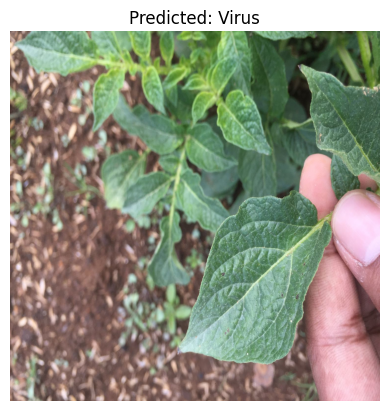

In [22]:
# Load model
model = PotatoCNN().to(DEVICE)
model.load_state_dict(torch.load("LeModelB.pth", map_location=DEVICE))
model.eval()

# Transform (same as validation/test)
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Random image from test set
random_image = random.choice(os.listdir(TEST_DIR))
image_path = os.path.join(TEST_DIR, random_image)

# Load and transform
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(DEVICE)

# Prediction
with torch.no_grad():
    output = model(input_tensor)
    _, predicted = torch.max(output, 1)
    predicted_label = CLASS_NAMES[predicted.item()]

# Display
plt.imshow(image)
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()